In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("earthquake_data.csv")  
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [3]:
print(df.shape) # to get the dimensions


(1000, 19)


In [4]:
print(df.columns.tolist()) # convert to list

['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']


In [5]:
print(df.info()) # data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [6]:
print(df.isnull().sum()) # gives the number of missing columns

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        551
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       6
continent    716
country      349
dtype: int64


In [7]:
# Remove duplicate rows

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (1000, 19)


In [8]:
#Extract month from date_time

df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["month"] = df["date_time"].dt.month

print(df[["date_time", "month"]].head())


            date_time  month
0 2023-08-16 12:47:00      8
1 2023-07-19 00:22:00      7
2 2023-07-17 03:05:00      7
3 2023-07-16 06:48:00      7
4 2023-07-16 06:48:00      7


C:\Users\Nithyashree Nataraj\AppData\Local\Temp\ipykernel_36160\3830416777.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")


In [9]:
# Keep only required columns + target

required_columns = [
    "magnitude",
    "depth",
    "latitude",
    "longitude",
    "nst",
    "dmin",
    "gap",
    "magType",
    "month",
    "tsunami"
]

df = df[required_columns]
df.head()


,magnitude,depth,latitude,longitude,nst,dmin,gap,magType,month,tsunami
0,6.5,192.955,-13.8814,167.1580,114,7.177000,25.0,mww,8,0
1,6.5,69.727,12.8140,-88.1265,92,0.679000,40.0,mww,7,0
2,6.6,171.371,-38.1911,-70.3731,70,1.634000,28.0,mww,7,0
3,7.2,32.571,54.3844,-160.6990,173,0.907000,36.0,mww,7,1
4,7.3,21.000,54.4900,-160.7960,79,0.879451,172.8,Mi,7,1


In [10]:
# Check missing values and clean target column

print(df.isnull().sum())

# Make sure target is numeric
df["tsunami"] = pd.to_numeric(df["tsunami"], errors="coerce")

# Drop rows where target is missing
df = df.dropna(subset=["tsunami"])

# Convert target to integer
df["tsunami"] = df["tsunami"].astype(int)

print(df["tsunami"].value_counts())


magnitude    0
depth        0
latitude     0
longitude    0
nst          0
dmin         0
gap          0
magType      0
month        0
tsunami      0
dtype: int64
tsunami
0    675
1    325
Name: count, dtype: int64


In [11]:
#  Separate features and target

X = df.drop("tsunami", axis=1)
y = df["tsunami"]

categorical_features = ["magType"]
numerical_features = [
    "magnitude",
    "depth",
    "latitude",
    "longitude",
    "nst",
    "dmin",
    "gap",
    "month"
]


In [12]:
df["depth_magnitude_ratio"] = df["depth"] / (df["magnitude"] + 1e-5)
df["shallow_quake"] = (df["depth"] < 70).astype(int)
df["strong_quake"] = (df["magnitude"] >= 6.5).astype(int)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [13]:
X = df.drop("tsunami", axis=1)
y = df["tsunami"]

categorical_features = ["magType"]

numerical_features = [
    "magnitude",
    "depth",
    "latitude",
    "longitude",
    "nst",
    "dmin",
    "gap",
    "month",
    "depth_magnitude_ratio",
    "shallow_quake",
    "strong_quake",
    "month_sin",
    "month_cos"
]


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier
    (
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred_rf = rf_model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.91

Confusion Matrix:
 [[126   9]
 [  9  56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       135
           1       0.86      0.86      0.86        65

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200



In [19]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


ROC-AUC Score: 0.9532193732193732


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Accuracy: 0.83

Confusion Matrix:
 [[105  30]
 [  4  61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.78      0.86       135
           1       0.67      0.94      0.78        65

    accuracy                           0.83       200
   macro avg       0.82      0.86      0.82       200
weighted avg       0.87      0.83      0.84       200


ROC-AUC Score: 0.8893447293447293


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=5
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))


Decision Tree Accuracy: 0.905

Confusion Matrix:
 [[123  12]
 [  7  58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       135
           1       0.83      0.89      0.86        65

    accuracy                           0.91       200
   macro avg       0.89      0.90      0.89       200
weighted avg       0.91      0.91      0.91       200


ROC-AUC Score: 0.9409686609686609


In [22]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_svm))


SVM Accuracy: 0.84

Confusion Matrix:
 [[107  28]
 [  4  61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.87       135
           1       0.69      0.94      0.79        65

    accuracy                           0.84       200
   macro avg       0.82      0.87      0.83       200
weighted avg       0.87      0.84      0.84       200


ROC-AUC Score: 0.9111111111111111


In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_knn))


KNN Accuracy: 0.84

Confusion Matrix:
 [[116  19]
 [ 13  52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       135
           1       0.73      0.80      0.76        65

    accuracy                           0.84       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.85      0.84      0.84       200


ROC-AUC Score: 0.909002849002849


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.910,0.861538,0.861538,0.861538,0.953219
1,Decision Tree,0.905,0.828571,0.892308,0.859259,0.940969
3,SVM,0.840,0.685393,0.938462,0.792208,0.911111
4,KNN,0.840,0.732394,0.800000,0.764706,0.909003
0,Logistic Regression,0.830,0.670330,0.938462,0.782051,0.889345


In [25]:
# for cleaner values
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.910,0.8615,0.8615,0.8615,0.9532
1,Decision Tree,0.905,0.8286,0.8923,0.8593,0.9410
3,SVM,0.840,0.6854,0.9385,0.7922,0.9111
4,KNN,0.840,0.7324,0.8000,0.7647,0.9090
0,Logistic Regression,0.830,0.6703,0.9385,0.7821,0.8893


In [26]:
best_model = results_df.iloc[0]
print("Best Model:")
print(best_model)


Best Model:
Model        Random Forest
Accuracy              0.91
Precision         0.861538
Recall            0.861538
F1-Score          0.861538
ROC-AUC           0.953219
Name: 2, dtype: object


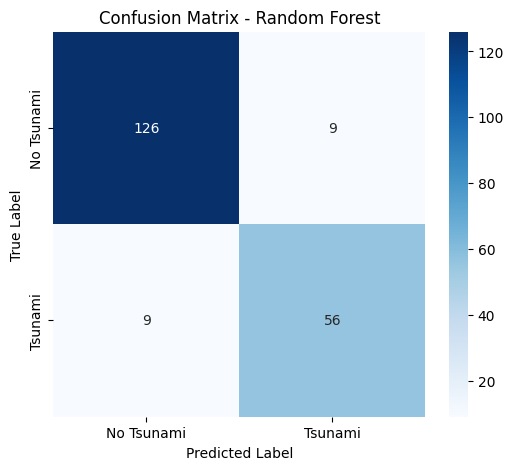

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tsunami", "Tsunami"],
            yticklabels=["No Tsunami", "Tsunami"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()


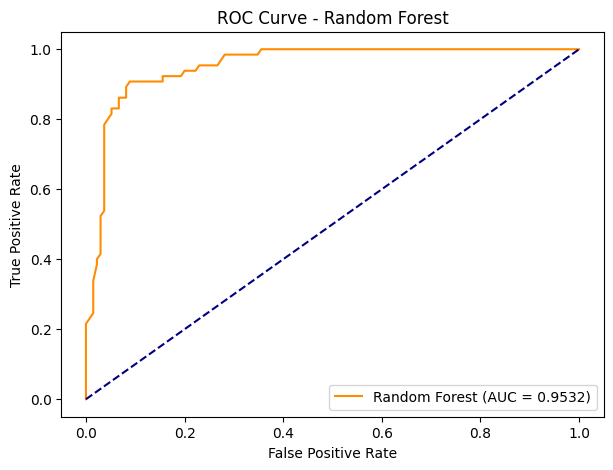

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="navy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


In [29]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)


,Feature,Importance
5,num__dmin,0.212152
21,cat__magType_mww,0.168743
4,num__nst,0.105976
3,num__longitude,0.100613
20,cat__magType_mwc,0.074789
6,num__gap,0.071908
2,num__latitude,0.068016
8,num__depth_magnitude_ratio,0.045679
1,num__depth,0.042140
0,num__magnitude,0.029077


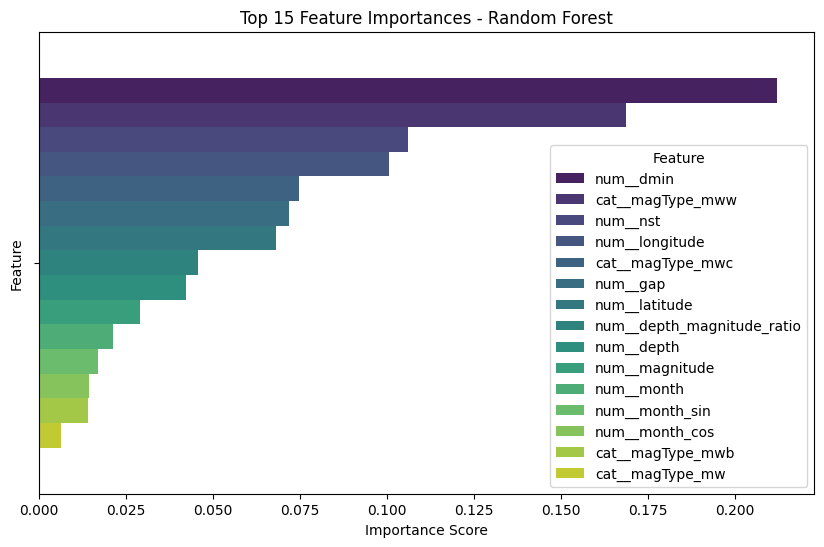

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    hue="Feature",
    palette="viridis",
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [36]:
import joblib
joblib.dump(rf_model, "tsunami_model.pkl")


['tsunami_model.pkl']

In [37]:
import joblib
model = joblib.load("tsunami_model.pkl")
